# DATA CLEANING AND PREPROCESSING

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import os
import re

import missingno as msno
import sys

from rapidfuzz import process, fuzz

import warnings
warnings.filterwarnings('ignore')


In [2]:
sys.path.append(os.path.abspath("../02_Src"))

from Compas.initial_exploration import read_file, initial_exploration
from Compas.preprocessing import convert_to_datetime, normalize_df, check_duplicate_column, fuzzy_replace_safe, remove_invisible_chars

## Load data

In [3]:
path = r'..\00_Data\00_Raw'

file_list = os.listdir(path)


In [4]:
data_dict = {}

for file in file_list:
    ruta_completa = os.path.join(path, file)
    df = read_file(ruta_completa)
    key = os.path.splitext(file.replace('-', '_'))[0]
    data_dict[key] = df

data_dict.keys()

dict_keys(['compas_scores_raw', 'compas_scores_two_years'])

## Initial exploration

EXPLORING: compas_scores_raw 

Rows and columns:


(60843, 28)

First five rows:


,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0




Last five rows:


...

Null values per column:


,Col,Null values
0,Person_ID,0
1,AssessmentID,0
2,Case_ID,0
3,Agency_Text,0
4,LastName,0
5,FirstName,0
6,MiddleName,45219
7,Sex_Code_Text,0
8,Ethnic_Code_Text,0
9,DateOfBirth,0


Null % per column:


,Col,Pct
0,MiddleName,74.32
1,ScoreText,0.07
2,Person_ID,0.00
3,CustodyStatus,0.00
4,IsCompleted,0.00
5,AssessmentType,0.00
6,DecileScore,0.00
7,RawScore,0.00
8,DisplayText,0.00
9,Scale_ID,0.00


## Null values: Visualization


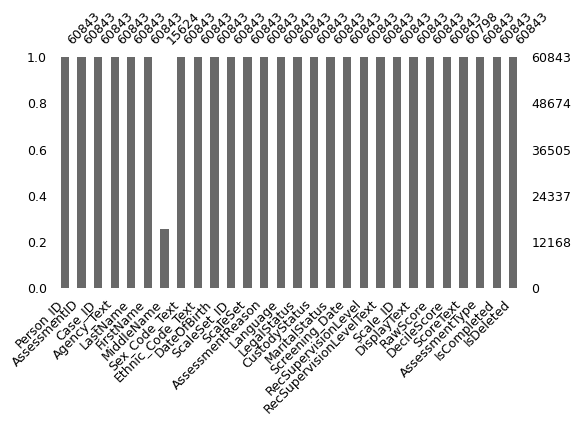

----------------------------------------------------------------------------------------------------
## Null values: Pattern visualization


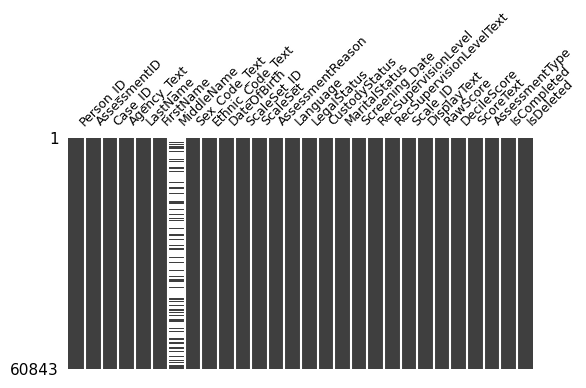

----------------------------------------------------------------------------------------------------
EXPLORING: compas_scores_two_years 

Rows and columns:


(7214, 53)

First five rows:


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0




Last five rows:


...

Null values per column:


,Col,Null values
0,id,0
1,name,0
2,first,0
3,last,0
4,compas_screening_date,0
5,sex,0
6,dob,0
7,age,0
8,age_cat,0
9,race,0


Null % per column:


,Col,Pct
0,violent_recid,100.00
1,vr_charge_degree,88.65
2,vr_case_number,88.65
3,vr_offense_date,88.65
4,vr_charge_desc,88.65
5,c_arrest_date,84.24
6,r_jail_out,67.90
7,r_jail_in,67.90
8,r_days_from_arrest,67.90
9,r_charge_desc,52.69


## Null values: Visualization


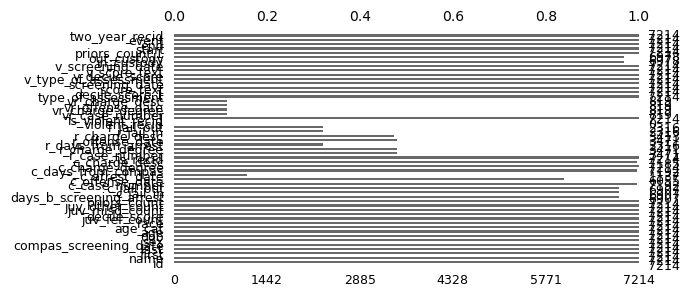

----------------------------------------------------------------------------------------------------
## Null values: Pattern visualization


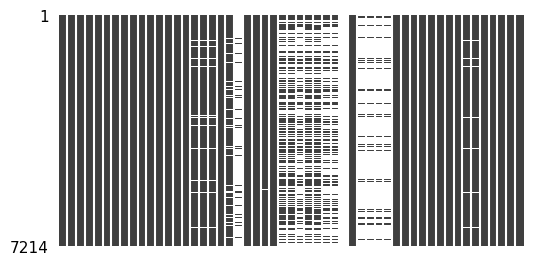

----------------------------------------------------------------------------------------------------


In [5]:
for k, v in data_dict.items():
    print(f"EXPLORING: {k} \n")
    initial_exploration(v)

## Data cleaning

In [6]:
df_compas_raw = data_dict['compas_scores_raw'].copy()
df_compas_two_years = data_dict['compas_scores_two_years'].copy()

df_compas_raw = convert_to_datetime(df_compas_raw)
df_compas_two_years = convert_to_datetime(df_compas_two_years)

df_compas_raw = normalize_df(df_compas_raw)
df_compas_two_years = normalize_df(df_compas_two_years)

In [7]:
check_duplicate_column(df_compas_two_years, "decile_score", "decile_score.1") # Empty dataframe = both columns are the exact same

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid


In [8]:
check_duplicate_column(df_compas_two_years, "priors_count", "priors_count.1")

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid


In [9]:
df_compas_raw["name"] = df_compas_raw["firstname"] + ' ' + df_compas_raw["lastname"] # To merge by full name

In [10]:
df_compas_raw = df_compas_raw.rename(columns={"dateofbirth" : "dob"})
df_compas_two_years = df_compas_two_years.rename(columns={"first":"firstname", "last": "lastname"})

In [11]:
# Varibles we want to keep for now

df_raw_variables = ['person_id',
 'agency_text',
 'name',
 'dob',
 'maritalstatus',
 'language',
 'rawscore'
]

df_two_years_variables = [
 'name',
 'sex',
 'race',
 'dob',
 'age',
 'age_cat',
 'decile_score',
 'v_decile_score',
 'is_recid',
 'is_violent_recid',
 'score_text',
 'screening_date',
 'two_year_recid',
 'priors_count',
 'c_charge_degree',
 'c_charge_desc',
 'start',
 'end',
 'event',
 'juv_fel_count',
 'juv_misd_count',
 'juv_other_count'
 ]

In [12]:
df_raw_clean = df_compas_raw[df_raw_variables].copy()
df_two_years_clean = df_compas_two_years[df_two_years_variables].copy()

display(df_raw_clean.columns)
display(df_two_years_clean.columns)

Index(['person_id', 'agency_text', 'name', 'dob', 'maritalstatus', 'language',
       'rawscore'],
      dtype='object')

Index(['name', 'sex', 'race', 'dob', 'age', 'age_cat', 'decile_score',
       'v_decile_score', 'is_recid', 'is_violent_recid', 'score_text',
       'screening_date', 'two_year_recid', 'priors_count', 'c_charge_degree',
       'c_charge_desc', 'start', 'end', 'event', 'juv_fel_count',
       'juv_misd_count', 'juv_other_count'],
      dtype='object')

In [13]:
df_raw_clean = df_raw_clean.drop_duplicates(subset=["person_id"])

In [14]:
# If is_recid = False, latest date is 2014-04-01. However that is not the case for is_recid = True. Making sure the time period is the same for both.
df_two_years_clean = df_two_years_clean[df_two_years_clean["screening_date"] <= pd.to_datetime('2014-04-01')]

In [15]:
df_raw_clean['dob'] = df_raw_clean['dob'].apply(lambda x : x - pd.DateOffset(years = 100) if x > pd.to_datetime('2000-01-01') else x)

In [16]:
#Name for merge

# Name misspelling
df_raw_clean["name"] = df_raw_clean.apply(
    lambda row: fuzzy_replace_safe(df_two_years_clean, "name", row),
    axis=1
)


# Getting rid of invisible characters
df_raw_clean["name"] = df_raw_clean["name"].apply(remove_invisible_chars)
df_two_years_clean["name"] = df_two_years_clean["name"].apply(remove_invisible_chars)

In [17]:
df_raw_sorted = df_raw_clean.sort_values("dob")
df_two_years_sorted = df_two_years_clean.sort_values("dob")

df_merge = pd.merge_asof(
    df_two_years_sorted,
    df_raw_sorted,
    on="dob",
    by=["name"],                # coincidencia exacta
    tolerance=pd.Timedelta(days=15),
    direction="nearest",      # el más cercano
    suffixes=("_master", "_raw")
)

In [18]:
# The age column provided in the dataset does not seem to be correct. Recalculating age using each individual's date of birth and screening date

df_merge["age_test"] = (
    df_merge["screening_date"].dt.year - df_merge["dob"].dt.year  
    - (
        (df_merge["screening_date"].dt.month < df_merge["dob"].dt.month)  # Hasn't had their birthday this year yet, -1 year old
        |
        (
            (df_merge["screening_date"].dt.month == df_merge["dob"].dt.month)
            &
            (df_merge["screening_date"].dt.day < df_merge["dob"].dt.day)
        )
    )
)

df_merge[["age", "age_test"]]

,age,age_test
0,96,94
1,83,80
2,83,79
3,80,77
4,79,76
...,...,...
6211,19,17
6212,19,17
6213,19,17
6214,19,17


In [19]:
# Get rid of original age column and rename the new one

df_merge = df_merge.drop(columns=["age"])
df_merge = df_merge.rename(columns={"age_test": "age"})

In [20]:
# Create an extra bin in age_cat

bins = [0, 26, 46, 66, 120]
labels = ['less than 25', '25-45', '46-65', 'greater than 65']

df_merge['age_cat'] = pd.cut(
    df_merge['age'],
    bins=bins,
    labels=labels,
    right=False
)

In [21]:
df_merge = df_merge.dropna(how = 'any')

In [22]:
df_merge["c_charge_degree"] = df_merge["c_charge_degree"].replace({'m' : 'misdemeanor', 'f' : 'felony'})

df_merge['juv_priors_count'] = df_merge['juv_fel_count'] + df_merge['juv_misd_count'] + df_merge['juv_other_count']

df_merge = df_merge.drop(columns=["dob", "name"])

In [23]:
# From priors_count, we get crimes exclusively commited by adults, and rename priors_count as total_priors_count
df_merge["adult_priors_count"] = np.where(
    df_merge["age"] < 18,
    0,
    (df_merge["priors_count"] - df_merge["juv_priors_count"]).clip(lower=0)
)


df_merge["priors_count"] = (df_merge["adult_priors_count"] + df_merge["juv_priors_count"])
df_merge = df_merge.rename(columns={"priors_count": "total_priors_count"})

In [25]:
df_merge.to_csv(r'..\00_Data\00_Processed\df_eda.csv', index=False)